# Лабораторная работа №2 — эксперименты

Здесь проверяю свои функции на настоящих данных и строю графики для второй части.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_tasks import analyze_titanic
from correlation_tasks import analyze_brain_correlations, FEATURES, TARGET
from grader_contracts.pandas_tasks import TitanicInput
from grader_contracts.correlation_tasks import BrainDataInput

## Часть 1. Titanic

In [2]:
titanic = analyze_titanic(TitanicInput("titanic.csv"))
titanic

TitanicSummary(row_count=891, missing_by_column={'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'Name': 0, 'Sex': 0, 'Age': 177, 'SibSp': 0, 'Parch': 0, 'Ticket': 0, 'Fare': 0, 'Cabin': 687, 'Embarked': 2}, adults_over_30_count=305, mean_age_by_pclass={1: 38.233440860215055, 2: 29.87763005780347, 3: 25.14061971830986}, survival_rate_by_pclass={1: 0.6296296296296297, 2: 0.47282608695652173, 3: 0.24236252545824846}, highest_fares=[512.3292, 512.3292, 512.3292, 263.0, 263.0])

Выводы:
- больше всего пропусков в `Cabin` и `Age`, поэтому при среднем возрасте пустые значения пропускаются, а не считаются нулями;
- чем выше класс, тем старше пассажиры и тем больше доля выживших (1-й класс — около 63%, 3-й — около 24%);
- самый дорогой билет — 512.33, его купили три пассажира, поэтому в топ-5 есть повторы.

## Часть 2. Корреляционный анализ

Таблица с разделителем tab, пропуски обозначены `NA`.

In [3]:
brain = pd.read_csv("brainsize.txt", sep="\t", na_values=["NA"])
print(brain.shape)
print(brain.isna().sum())
brain.head()

(40, 7)
Gender       0
FSIQ         0
VIQ          0
PIQ          0
Weight       2
Height       1
MRI_Count    0
dtype: int64


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
0,Female,133,132,124,118.0,64.5,816932
1,Male,140,150,124,NaN,72.5,1001121
2,Male,139,123,150,143.0,73.3,1038437
3,Male,133,129,128,172.0,68.8,965353
4,Female,137,132,134,147.0,65.0,951545


In [4]:
result = analyze_brain_correlations(BrainDataInput("brainsize.txt"))
result

BrainCorrelationSummary(men_count=20, women_count=20, women_mri_correlation={'FSIQ': 0.32569670049637045, 'VIQ': 0.25493285296147666, 'PIQ': 0.3961571668684764, 'Weight': 0.44627135266164303, 'Height': 0.17454104728809816}, men_mri_correlation={'FSIQ': 0.4983691104171924, 'VIQ': 0.4131049601428287, 'PIQ': 0.5682370032144156, 'Weight': -0.07687464371333168, 'Height': 0.3015430401770575}, strongest_mri_feature='PIQ')

In [5]:
table = pd.DataFrame({
    "Женщины": result.women_mri_correlation,
    "Мужчины": result.men_mri_correlation,
}).round(3)
table

,Женщины,Мужчины
FSIQ,0.326,0.498
VIQ,0.255,0.413
PIQ,0.396,0.568
Weight,0.446,-0.077
Height,0.175,0.302


### Scatter-графики: каждый признак против MRI_Count

Каждая точка — один человек. Если облако точек вытянуто вверх-вправо, корреляция положительная.

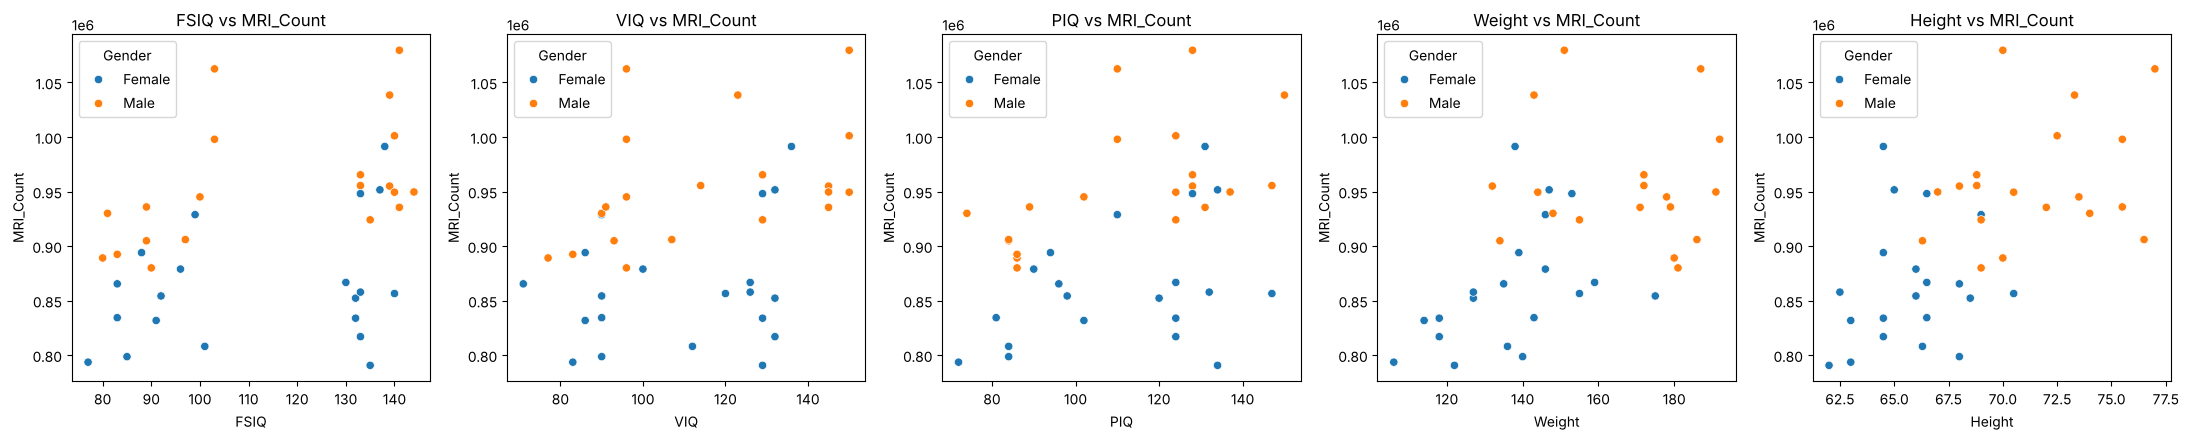

In [6]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(22, 4.5))
for ax, feature in zip(axes, FEATURES):
    sns.scatterplot(data=brain, x=feature, y=TARGET, hue="Gender", ax=ax)
    ax.set_title(f"{feature} vs {TARGET}")
plt.tight_layout()
plt.show()

### Heatmap корреляций по группам

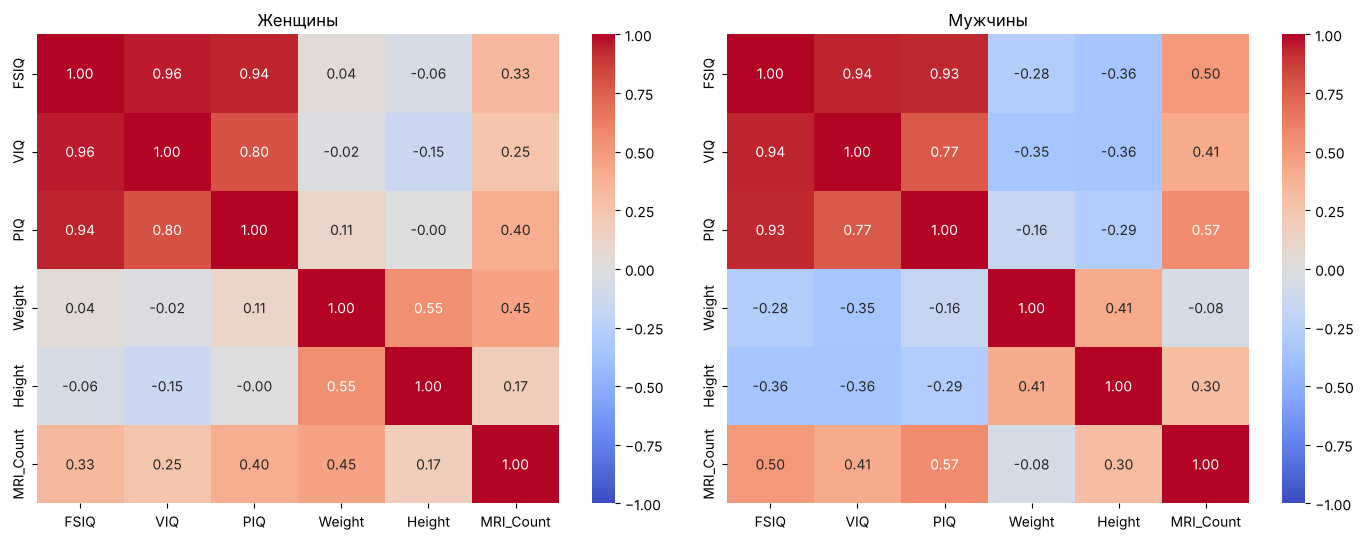

In [7]:
numeric = FEATURES + [TARGET]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (title, gender) in zip(axes, [("Женщины", "Female"), ("Мужчины", "Male")]):
    corr = brain[brain["Gender"] == gender][numeric].corr(method="pearson")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()

Выводы:
- у мужчин размер мозга сильнее всего связан с `PIQ` (r ≈ 0.57) — это и есть `strongest_mri_feature`;
- у женщин сильнее всего связь с `Weight` (r ≈ 0.45), а у мужчин вес почти не связан с размером мозга (r ≈ −0.08);
- в целом связи умеренные: при 20 людях в группе такие коэффициенты могут заметно меняться от выборки к выборке;
- корреляция показывает только совместное изменение, а не то, что одно вызывает другое.